# 🎬 Movie Rating Prediction – Final Assignment Part 2
### Gil Hatiel | Machine Learning Course

## ⚙️ Imports & Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Style – מוגדר פעם אחת, חל על כל הגרפים
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size']      = 13
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.titlepad']     = 10

SEED = 42
np.random.seed(SEED)

GREEN  = '#2ecc71'
RED    = '#e74c3c'
BLUE   = '#3498db'
ORANGE = '#f39c12'

print('✅ All set!')

✅ All set!


---
## 🔍 Part 1: Exploratory Data Analysis (EDA)

### What are we looking at?
Before touching anything, we need to understand what we have.
Three questions to answer:
1. What is the shape of the data?
2. What do the values look like?
3. What is missing?

In [7]:
# ---------------------------------------------------------------
# 1.0  Load & First Look
# ---------------------------------------------------------------
df_raw = pd.read_csv('dataset.csv', low_memory=False)

In [8]:
# כמה שורות ועמודות יש?
print(f'📦 Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

📦 Shape: 133,884 rows × 13 columns


In [9]:
# הצגת 5 שורות אקראיות
df_raw.sample(5, random_state=SEED)

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
3115,tt1507306,Jangan Pandang Belakang Congkak,2009.0,"Comedy,Fantasy,Horror","['nm0784094', 'nm3603389', 'nm3603159', 'nm360...",90.0,3.4,NaN,NaN,87.0,NaN,NaN,NaN
14399,tt7520068,Kolej Havasi,2019.0,Documentary,"['nm11454310', 'nm11454313', 'nm11454314', 'nm...",105.0,8.7,NaN,NaN,259.0,NaN,NaN,NaN
132162,tt7021508,Honey: Rise Up and Dance,2018.0,"Drama,Music","nm3692520, nm7005977, nm2057826, nm0496980, nm...",100.0,5.0,NaN,NaN,1013.0,NaN,NaN,NaN
94863,tt22898390,Anmitsu hime: Yôjutsu kurabe no maki,1954.0,NaN,"['nm0950825', 'nm0473530', 'nm1090569', 'nm178...",65.0,NaN,NaN,NaN,0.0,NaN,NaN,"Anmitsu Hime ( あんみつ姫 ; ""Princess Anmitsu "") is..."
27537,tt0466456,Midsummer Madness,2007.0,"[""Comedy"", ""Drama"", ""Romance""]","[""nm0684500"", ""nm0920366"", ""nm1616309"", ""nm060...",94.0,5.9,Latvian,Latvia,625.0,3.5,NaN,NaN


In [10]:
# מה סוג הנתונים בכל עמודה
df_raw.dtypes

tconst              object
primaryTitle        object
startYear          float64
genres              object
lead_actors_ids     object
runtimeMinutes     float64
averageRating      float64
Language            object
Country             object
numVotes           float64
budget              object
BoxOffice          float64
plot                object
dtype: object

In [11]:
# ---------------------------------------------------------------
# 1.2  Statistical summary רק על העמודות המספריות
# ---------------------------------------------------------------

df_raw.describe().round(2)

,startYear,runtimeMinutes,averageRating,numVotes,BoxOffice
count,133884.00,133884.00,115560.00,124762.00,1.791600e+04
mean,1995.64,97.24,6.07,7562.01,4.705076e+07
std,64.75,22.92,1.29,54834.44,2.894113e+09
min,0.00,60.00,1.00,0.00,0.000000e+00
25%,1982.00,84.00,5.30,36.00,1.000000e+00
50%,2007.00,93.00,6.20,173.00,7.900000e+00
75%,2017.00,106.00,7.00,879.00,6.095000e+01
max,2026.00,300.00,10.00,3186698.00,3.120000e+11


In [12]:
 ## 1.3  Missing values analysis נבדוק כמה חסר בכל עמודה
missing = pd.DataFrame({
    'missing_count': df_raw.isnull().sum(),
    'missing_%':     (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('missing_%', ascending=False)

display(missing)

,missing_count,missing_%
budget,117334,87.6
BoxOffice,115968,86.6
Country,80203,59.9
Language,78162,58.4
plot,74215,55.4
averageRating,18324,13.7
lead_actors_ids,10030,7.5
numVotes,9122,6.8
genres,2573,1.9
tconst,0,0.0


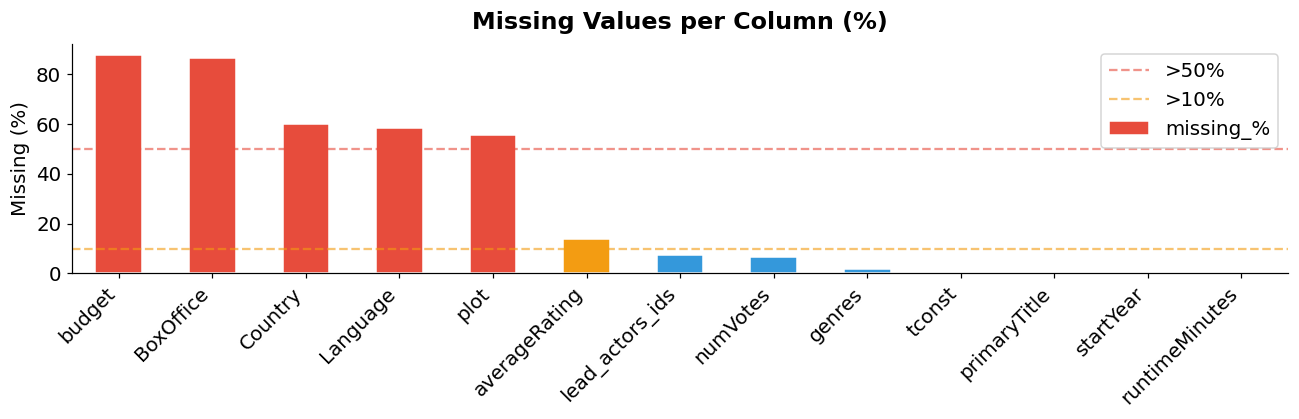

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
colors = [RED if p > 50 else ORANGE if p > 10 else BLUE
          for p in missing['missing_%']]
missing['missing_%'].plot(kind='bar', ax=ax, 
                          color=colors, edgecolor='white')
ax.set_title('Missing Values per Column (%)', fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.axhline(50, color=RED,    linestyle='--', alpha=0.6, label='>50%')
ax.axhline(10, color=ORANGE, linestyle='--', alpha=0.6, label='>10%')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

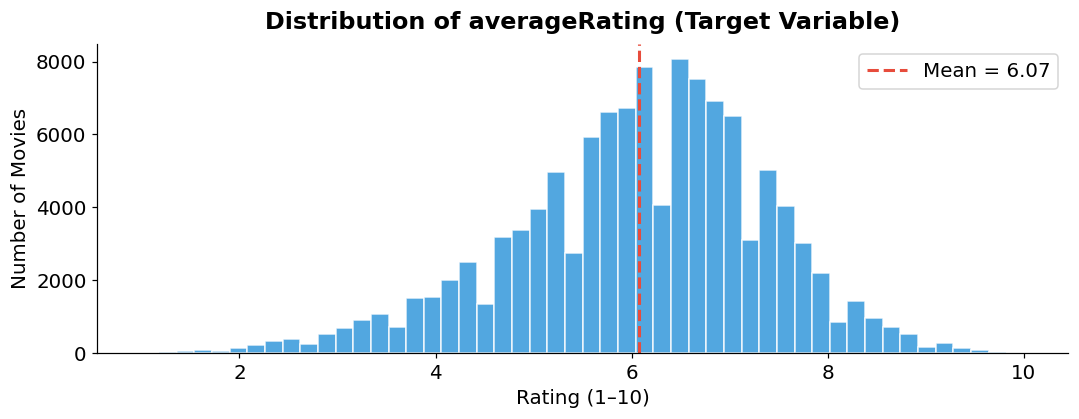

In [14]:
# 1.4  Target variable – averageRating
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_raw['averageRating'].dropna(), bins=50,
        color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(df_raw['averageRating'].mean(), color=RED,
           linestyle='--', linewidth=2,
           label=f'Mean = {df_raw["averageRating"].mean():.2f}')
ax.set_title('Distribution of averageRating (Target Variable)', 
             fontweight='bold')
ax.set_xlabel('Rating (1–10)')
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.show()

### Initial Data Understanding

The dataset contains 133,884 movie records and 13 columns.  
The target variable is `averageRating`, which represents the average IMDb rating of each movie.

From the initial inspection, the dataset contains both numerical and categorical/textual features.  
Numerical columns include `startYear`, `runtimeMinutes`, `averageRating`, `numVotes`, and `BoxOffice`.  
Categorical or textual columns include `tconst`, `primaryTitle`, `genres`, `lead_actors_ids`, `Language`, `Country`, `budget`, and `plot`.

The target variable `averageRating` ranges from 1 to 10, with an average value of approximately 6.07 and a median of 6.2.  
This suggests that most movies in the dataset are rated around the middle-high range, while very low or very high ratings are less common.

A major issue in the dataset is missing values. Some columns have a very high percentage of missing data, especially `budget`, `BoxOffice`, `Country`, `Language`, and `plot`.  
Therefore, simply removing rows with missing values would cause a significant loss of data. Later stages should handle missing values using imputation or by creating informative missingness indicators.

The column `budget` is stored as an object rather than a numerical column, meaning it requires cleaning before it can be used as a feature.  
In addition, `startYear` contains suspicious values such as 0, which should be handled during the data preparation stage.

Finally, although `numVotes` and `BoxOffice` appear in the dataset, they will not be used as model features because they represent information that is only available after a movie is released and may cause data leakage.

In [15]:
# 1.5  Data Quality Checks
df_raw.duplicated().sum()

np.int64(0)

In [16]:
# כפילויות לפי tconst
df_raw['tconst'].duplicated().sum()

np.int64(0)

In [17]:
# ערכי startYear חשודים
df_raw[df_raw['startYear'] < 1888]

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
64465,tt10209920,Alien Wars: Judgement Day,0.0,['Sci-Fi'],"['nm3782241', 'nm0357405', 'nm0245223', 'nm177...",90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64533,tt3580466,Alhambra Decree 1492,0.0,"['Adventure', 'Drama', 'History']","['nm0537631', 'nm0001934', 'nm2454994', 'nm106...",110.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64627,tt4764536,Action Not Words,0.0,['Action'],"['nm0584473', 'nm4106347', 'nm2335825', 'nm914...",91.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64687,tt3116542,Alam High School,0.0,"['Documentary', 'History']",['nm0013037'],150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64828,tt7727364,All That Ends,0.0,['Drama'],['nm9164025'],90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71658,tt14998708,Agent Surya,0.0,"['Crime', 'Mystery', 'Thriller']",['nm8242827'],120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71761,tt41141748,All That's Left,0.0,"['Drama', 'Sci-Fi']","['nm7956133', 'nm6672073', 'nm15672591', 'nm09...",85.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71816,tt1662622,Aleya's Tango: Dreams of a Vampyre,0.0,"['Drama', 'Fantasy', 'Musical']","['nm3935935', 'nm3223702', 'nm3927793', 'nm392...",82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71855,tt35681860,Almost Blue,0.0,"['Crime', 'Drama']","['nm17002694', 'nm17002692', 'nm17002697', 'nm...",88.0,NaN,Italian,Italy,NaN,NaN,NaN,NaN


In [18]:
# כמה ז'אנרים ייחודיים יש?
df_raw['genres'].nunique()

2225

In [19]:
# אילו זאנרים הכי נפוצים בדאטה?
genres_split = df_raw['genres'].dropna().str.replace(r"[\[\]'\"]", '', regex=True)
genres_split = genres_split.str.split(',').explode().str.strip()
genres_split.value_counts().head(15)

genres
Drama          64056
Comedy         35201
Documentary    18264
Romance        16584
Action         14862
Crime          13017
Thriller       12296
Horror         10371
Adventure       8657
Mystery         5874
Family          5332
Biography       4641
Fantasy         4414
Music           3765
History         3757
Name: count, dtype: int64

In [20]:
# האם יש סרטים עם כמה ז'אנרים?
df_raw['genres'].dropna().sample(10, random_state=SEED)

99501                           Horror
52515                       ['Comedy']
123260                          Comedy
56892                           Comedy
10238                           Comedy
22659     ["Comedy", "Crime", "Drama"]
31858             ['Drama', 'Romance']
92674                           Comedy
32120                        ['Drama']
129685                   Comedy,Horror
Name: genres, dtype: object

> **Two formats detected:** `"Comedy,Horror"` and `['Drama', 'Romance']`.
Brackets and quotes must be cleaned and unified before processing.

In [21]:
df_raw['Country'].dropna().sample(25, random_state=SEED)

75971                                       United States
48319                                        Soviet Union
119901                                          Not Found
22195                                       United States
24169                                              Sweden
89825                                       United States
122771                                              India
59948                                          Azerbaijan
43544                            United States of America
112694                                      United States
117104                                      United States
50198                                    Hong Kong, China
94336                                         Philippines
41969                                      United Kingdom
36977                                              Canada
83028                                      United Kingdom
48003                                              Brazil
72512         

> The Country column contains inconsistent notations for the same country (e.g., "United States" vs. "United States of America" vs. "US"), multi-country entries separated by commas, and citation artifacts like Italy[1]. Cleaning and normalization are required before determining the Top 15 countries.

In [22]:
# בעיות שזוהו בעמודת Country
print('Multi-country entries:', df_raw['Country'].str.contains(',', na=False).sum())
print('List format:',           df_raw['Country'].str.startswith('[', na=False).sum())
print('Citation artifacts:',    df_raw['Country'].str.contains(r'\[\d+\]', na=False, regex=True).sum())

Multi-country entries: 2037
List format: 355
Citation artifacts: 73


In [23]:
df_raw['Country'].fillna('').str.replace(r"[\[\]'\"]", '', regex=True).str.strip().value_counts().head(15)

Country
                  80203
United States     19431
India              7132
United Kingdom     2644
France             1740
Italy              1680
Not Found          1645
Japan              1522
Canada             1154
Spain               747
South Korea         735
Germany             696
Hong Kong           689
Australia           621
Mexico              508
Name: count, dtype: int64

Country column normalization: the column contained inconsistent notations 
(e.g. "US", "U.S", "USA" for the same country). I asked Claude to suggest 
possible variants for each country. I then manually validated each variant 
against the actual data and confirmed the final Top 15 countries and their 
counts after unification.

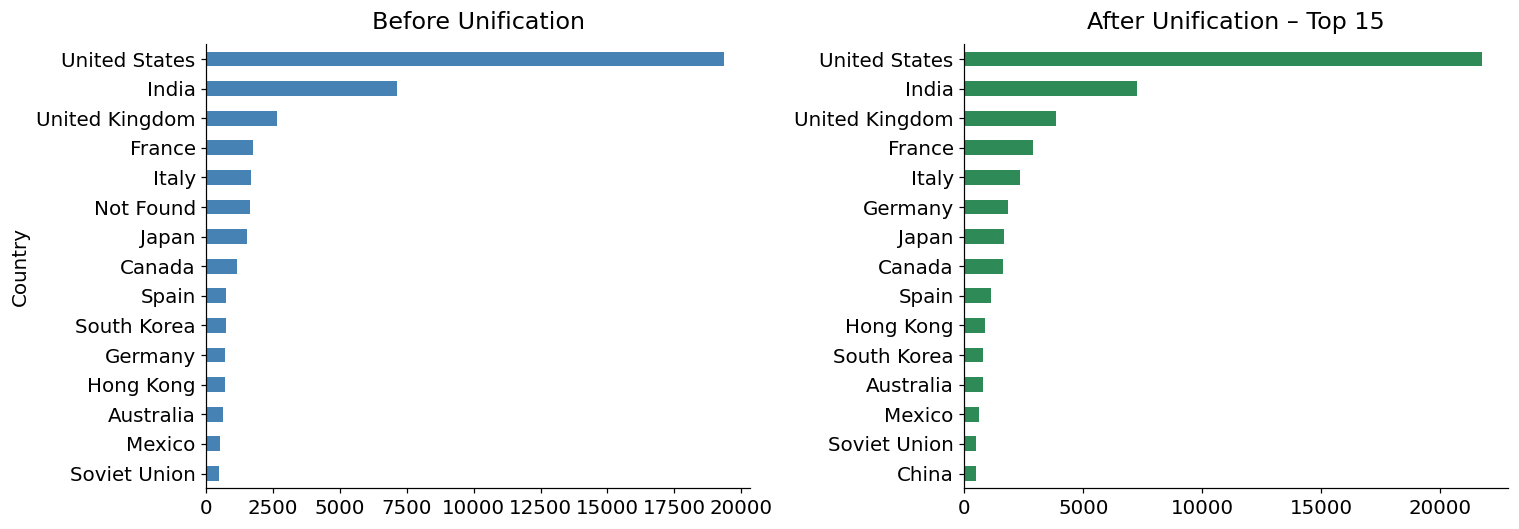

In [24]:
# טופ 15 לפני ואחרי איחוד
# לפני: ספירה גולמית ללא טיפול בוריאציות
# אחרי: לאחר איחוד כל הוריאציות (בסיוע AI + ולידציה ידנית)

after = {'United States':21766, 'India':7242, 'United Kingdom':3868,
         'France':2898,  'Italy':2326,  'Germany':1821, 'Japan':1687,
         'Canada':1630,  'Spain':1113,  'Hong Kong':858, 'South Korea':784,
         'Australia':768,'Mexico':632,  'Soviet Union':507, 'China':505}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_raw['Country'].dropna().value_counts().head(15).plot(
    kind='barh', ax=axes[0], color='steelblue', title='Before Unification')
axes[0].invert_yaxis()

pd.Series(after).sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen', title='After Unification – Top 15')

plt.tight_layout()
plt.show()

In [25]:
# כמה ערכים ייחודיים יש בעמודת Country?
df_raw['Country'].nunique()

2532

In [26]:
# מה נראה ב-lead_actors_ids?
df_raw['lead_actors_ids'].dropna().sample(5, random_state=SEED)

82437     ['nm0680983', 'nm0644897', 'nm0013037', 'nm185...
83108     ['nm0846070', 'nm0814033', 'nm0434223', 'nm071...
50652     ['nm0058181', 'nm0087142', 'nm0160945', 'nm019...
80415     ['nm4404734', 'nm0911854', 'nm4178142', 'nm523...
121940    nm1156207, nm4539846, nm2636694, nm4540117, nm...
Name: lead_actors_ids, dtype: object

> **lead_actors_ids column:** two formats detected –
> list format `['nm001', 'nm002']` and plain string `nm001, nm002`.
> Regex will be used to count actors correctly in both cases.

In [27]:
# מספר שחקנים לסרט – regex עובד על שני הפורמטים
n_act = df_raw['lead_actors_ids'].apply(
    lambda x: len(re.findall(r'nm\d+', str(x))) if pd.notna(x) else np.nan
)
n_act.value_counts(dropna=False).sort_index()

lead_actors_ids
0.0     8873
1.0     3934
2.0     3599
3.0     5302
4.0     5832
5.0    96314
NaN    10030
Name: count, dtype: int64

In [28]:
# כמה ערכים יש בעמודת Language?
print(f'ערכים ייחודיים: {df_raw["Language"].nunique():,}')
print(f'חסרים: {df_raw["Language"].isna().sum():,} ({df_raw["Language"].isna().sum()/len(df_raw)*100:.1f}%)')

ערכים ייחודיים: 2,936
חסרים: 78,162 (58.4%)


In [29]:
# מה השפות הנפוצות ביותר?
df_raw['Language'].value_counts().head(15)

Language
English      26332
Hindi         2344
French        2217
Spanish       1953
Italian       1822
Not Found     1645
Japanese      1479
Tamil         1294
German        1100
Telugu        1032
Malayalam     1009
Russian        763
Korean         685
Cantonese      529
Mandarin       501
Name: count, dtype: int64

In [30]:
# כמה סרטים יש עם אנגלית (כולל סרטים עם כמה שפות)
has_english = df_raw['Language'].str.contains('english', case=False, na=False).sum()
print(f'סרטים עם אנגלית: {has_english:,} ({has_english/len(df_raw)*100:.1f}%)')

סרטים עם אנגלית: 29,432 (22.0%)


In [31]:
crew  = pd.read_csv('title.crew.tsv',  sep='\t', na_values='\\N',
                    usecols=['tconst', 'directors'])
names = pd.read_csv('name.basics.tsv', sep='\t', na_values='\\N',
                    usecols=['nconst', 'primaryName'])

In [32]:
crew['director_id'] = crew['directors'].str.split(',').str[0]
crew = crew.merge(names, left_on='director_id', right_on='nconst', how='left')
df_raw = df_raw.merge(crew[['tconst','primaryName']], on='tconst', how='left')
df_raw = df_raw.rename(columns={'primaryName': 'director'})

# כמה חסרים?
missing = df_raw['director'].isna().sum()
print(f'חסרים: {missing:,} ({missing/len(df_raw)*100:.1f}%)')

# top במאים
df_raw['director'].value_counts().head(20)

חסרים: 1,267 (0.9%)


director
Kinya Ogawa           103
Jesús Franco           84
Satoru Kobayashi       78
William Beaudine       76
Michael Curtiz         60
Lesley Selander        60
Osman F. Seden         56
Yōji Yamada            54
Lloyd Bacon            53
Kaoru Umezawa          53
Priyadarshan           52
Lew Landers            51
Masahiro Makino        50
Sakae Nitta            49
Atıf Yılmaz            48
Gérard Courant         47
Mamoru Watanabe        47
K. Raghavendra Rao     46
Frank McDonald         45
Orhan Aksoy            45
Name: count, dtype: int64

In [33]:
# במאים עם הכי הרבה סרטים + ממוצע דירוג גבוה
df_raw.groupby('director')['averageRating'].agg(['count','mean'])\
      .query('count >= 10')\
      .sort_values('mean', ascending=False)\
      .head(20).round(2)

,count,mean
director,,
Christopher Nolan,11,8.25
S.K. Bhagavan,16,8.11
Satyajit Ray,14,8.06
Hayao Miyazaki,12,7.93
Tapan Sinha,15,7.90
Masaki Kobayashi,10,7.86
P. Ramlee,17,7.84
Abbas Kiarostami,10,7.67
Akira Kurosawa,18,7.65


**🎬 Director Feature Selection – Methodology**

From the ranked list of directors (minimum 10 films, sorted by average rating),
I selected the top 5 using a combined score:

**Selection criterion:** `number of films × (avg_rating − 6.07)`

where 6.07 is the overall average rating in the dataset — the model's "baseline guess" 
with no information. The further a director's average is from 6.07, the stronger the signal.

| Director | Films | Avg Rating | Score |
|---|---|---|---|
| Martin Scorsese | 30 | 7.60 | 45.9 |
| Steven Spielberg | 26 | 7.40 | 34.6 |
| Akira Kurosawa | 18 | 7.65 | 28.4 |
| Hayao Miyazaki | 12 | 7.93 | 22.3 |
| Christopher Nolan | 11 | 8.25 | 24.0 |

These five directors have the strongest and most reliable signal in the data —
their films consistently rate well above the dataset average.

In [58]:
# בחירה מבוססת מוניטין חיצוני (Oscar, IMDb Top 250, ביקורת בינלאומית)
# ללא שימוש ב-averageRating מהדאטה
CANDIDATES = [
    'Christopher Nolan', 'Martin Scorsese', 'Steven Spielberg',
    'Akira Kurosawa', 'Hayao Miyazaki', 'Stanley Kubrick',
    'Billy Wilder', 'Satyajit Ray', 'Bong Joon-ho', 
    'Francis Ford Coppola'
]

# בדיקה שיש להם מספיק סרטים בדאטה (count בלבד - לא rating)
counts = df_raw[df_raw['director'].isin(CANDIDATES)]\
    .groupby('director').size().sort_values(ascending=False)
print(counts)

director
Martin Scorsese         30
Steven Spielberg        26
Billy Wilder            20
Akira Kurosawa          18
Francis Ford Coppola    18
Satyajit Ray            14
Hayao Miyazaki          12
Christopher Nolan       11
Stanley Kubrick          9
dtype: int64


In [57]:
# פיצוץ השחקנים + ממוצע דירוג
actors_flat = df_raw[['lead_actors_ids','averageRating']].dropna()
actors_flat['nconst'] = actors_flat['lead_actors_ids'].apply(
    lambda x: re.findall(r'nm\d+', str(x))
)
actors_flat = actors_flat.explode('nconst')

actor_stats = actors_flat.groupby('nconst')['averageRating']\
    .agg(['count','mean']).query('count >= 10')
actor_stats['score'] = actor_stats['count'] * (actor_stats['mean'] - 6.07)
actor_stats = actor_stats.sort_values('score', ascending=False)

names = pd.read_csv('name.basics.tsv', sep='\t', na_values=r'\N',
                    usecols=['nconst','primaryName'])
actor_stats = actor_stats.merge(names, on='nconst').head(20)
display(actor_stats[['primaryName','count','mean','score']].round(2))

,primaryName,count,mean,score
0,Kamal Haasan,108,7.22,124.04
1,Rajkumar,46,8.68,119.88
2,Mohanlal,189,6.70,119.07
3,K.S. Ashwath,50,7.95,93.90
4,Mohan Babu,85,7.12,89.35
5,Soumitra Chatterjee,67,7.27,80.21
6,Mammootty,180,6.50,77.20
7,T.N. Balakrishna,34,8.21,72.92
8,Anant Nag,57,7.34,72.41
9,Kemal Sunal,57,7.25,67.21


In [59]:
# שחקנים לפי כמות הופעות (ללא שימוש ב-rating)
actors_flat = df_raw[['lead_actors_ids']].dropna().copy()
actors_flat['nconst'] = actors_flat['lead_actors_ids'].apply(
    lambda x: re.findall(r'nm\d+', str(x))
)
actors_flat = actors_flat.explode('nconst')

actor_counts = actors_flat.groupby('nconst').size()\
    .reset_index(name='count')\
    .query('count >= 10')\
    .sort_values('count', ascending=False)

names = pd.read_csv('name.basics.tsv', sep='\t', na_values=r'\N',
                    usecols=['nconst','primaryName'])

actor_counts = actor_counts.merge(names, on='nconst').head(30)
print(actor_counts[['primaryName','count']].to_string())

           primaryName  count
0         Brahmanandam    197
1             Mohanlal    189
2            Mammootty    180
3          Prakash Raj    143
4         Eric Roberts    136
5          Anupam Kher    133
6               Nassar    128
7   Mithun Chakraborty    128
8           Dharmendra    121
9     Amitabh Bachchan    117
10        Akshay Kumar    113
11   Tanikella Bharani    112
12        Kamal Haasan    108
13   Jagathy Sreekumar    106
14        Cüneyt Arkin    102
15       Nedumudi Venu    102
16             Jayaram     98
17       Shakti Kapoor     98
18    Gérard Depardieu     96
19         Rajinikanth     96
20    Masayoshi Nogami     96
21        Paresh Rawal     95
22         Sanjay Dutt     91
23             Om Puri     91
24            Siddique     90
25             Avinash     89
26         Ashok Kumar     88
27        Mohammad Ali     87
28          Ajay Devgn     86
29       Jackie Shroff     86


## 🧹 Part 2: `prepare_data` Function

This function receives the raw DataFrame (as collected in Part 1) and returns 
a clean, model-ready DataFrame containing only the relevant features.

### ⚠️ Data Leakage Prevention
The first action inside the function is dropping the three leakage columns —
before any other processing:
- `averageRating` – the target variable itself
- `numVotes` – accumulates only after release
- `BoxOffice` – revenue accumulates only after release

### 🔧 Engineered Features
| # | Feature | Formula | Type |
|---|---------|---------|------|
| 1 | `genre_X` | Top 15 genres → binary columns (1 if movie belongs to genre) | binary |
| 2 | `runtime_cat` | short (≤80 min) / medium (81–120) / long (>120) / no_data | binning  |
| 3 | `decade` | startYear // 10 × 10 | numeric |
| 4 | `has_plot` | 1 if plot description exists, 0 if missing | binary |
| 5 | `country_X` | Top 15 countries → binary columns (primary country only) | binary |

### 📌 Design Decisions
- **`budget` and `plot` columns are dropped** — both have extremely high 
  missing rates and are not reliable predictors.
- **`runtime_cat`** uses a custom function instead of `pd.cut` to correctly 
  handle zero and missing values as a dedicated `no_data` category.
- **Country column** required cleaning before encoding: multiple countries 
  per cell, citation artifacts (e.g. `Italy[1]`), and name variants 
  (

In [34]:
def prepare_data(df):
    df = df.copy()

    # STEP 1: Drop rows with missing target + leakage columns
    if 'averageRating' in df.columns:
        df = df.dropna(subset=['averageRating'])

    leakage_cols = ['averageRating', 'numVotes', 'BoxOffice']
    df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

    # STEP 2: Clean numeric base columns
    df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce')
    df.loc[df['startYear'] < 1888, 'startYear'] = np.nan
    df['year_missing'] = df['startYear'].isna().astype(int)
    df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')

    # STEP 3: n_actors + actors_missing
    df['actors_missing'] = df['lead_actors_ids'].isna().astype(int)
    df['n_actors'] = df['lead_actors_ids'].apply(
        lambda x: len(re.findall(r'nm\d+', str(x))) if pd.notna(x) else 0
    )

    # STEP 4: Feature 1 – genre binary columns (top 15)
    TOP_GENRES = [
        'Drama', 'Comedy', 'Documentary', 'Romance', 'Action',
        'Crime', 'Thriller', 'Horror', 'Adventure', 'Mystery',
        'Family', 'Biography', 'Fantasy', 'Music', 'History'
    ]

    def clean_genres(val):
        if pd.isna(val):
            return []
        val = re.sub(r"[\[\]'\"]", '', str(val))
        return [g.strip() for g in val.split(',') if g.strip()]

    genres_parsed = df['genres'].apply(clean_genres)
    for genre in TOP_GENRES:
        df[f'genre_{genre}'] = genres_parsed.apply(lambda g: int(genre in g))

    # STEP 5: Feature 2 – runtime_cat
    def categorize_runtime(val):
        if pd.isna(val) or val == 0: return 'no_data'
        elif val <= 80:              return 'short'
        elif val <= 120:             return 'medium'
        else:                        return 'long'

    df['runtime_cat'] = df['runtimeMinutes'].apply(categorize_runtime)

    # STEP 6: Feature 3 – decade
    df['decade'] = (df['startYear'] // 10 * 10)

    # STEP 7: Feature 4 – is_english + language_missing
    df['is_english'] = df['Language'].str.contains(
        'english', case=False, na=False
    ).astype(int)

    df['language_missing'] = (
        df['Language'].isna() |
        (df['Language'].str.strip().str.lower() == 'not found')
    ).astype(int)

    # STEP 8: Feature 5 – country binary columns (top 15)
    TOP_COUNTRIES = [
        'United States', 'India', 'United Kingdom', 'France', 'Italy',
        'Germany', 'Japan', 'Canada', 'Spain', 'Hong Kong',
        'South Korea', 'Australia', 'Mexico', 'Soviet Union', 'China'
    ]

    def clean_country_string(val):
        if pd.isna(val): return ''
        val = str(val)
        val = re.sub(r'\[\s*\d+\s*\]', '', val)
        val = re.sub(r'\(.*?\)', '', val)
        val = re.sub(r"[\[\]'\"]", '', val)
        val = val.replace('|', ',')
        val = val.replace('United States of America', 'United States')
        val = re.sub(r'\bU\.S\.A\.?\b',  'United States',  val)
        val = re.sub(r'\bU\.S\.?(?!S)',   'United States',  val)
        val = re.sub(r'\bUSA\b',          'United States',  val)
        val = re.sub(r'\bUS\b',           'United States',  val)
        val = re.sub(r'\bU\.K\.?\b',      'United Kingdom', val)
        val = re.sub(r'\bUK\b',           'United Kingdom', val)
        val = val.replace('Great Britain',    'United Kingdom')
        val = val.replace('Northern Ireland', 'United Kingdom')
        val = re.sub(r'\bBritain\b',  'United Kingdom', val)
        val = re.sub(r'\bEngland\b',  'United Kingdom', val)
        val = re.sub(r'\bScotland\b', 'United Kingdom', val)
        val = re.sub(r'\bWales\b',    'United Kingdom', val)
        val = val.replace('West Germany',    'Germany')
        val = val.replace('East Germany',    'Germany')
        val = val.replace('Nazi Germany',    'Germany')
        val = val.replace('Weimar Republic', 'Germany')
        val = val.replace('British Hong Kong', 'Hong Kong')
        val = val.replace('Republic of Korea', 'South Korea')
        val = val.replace('Korea South',        'South Korea')
        val = re.sub(r'\bU\.S\.S\.R\.?\b', 'Soviet Union', val)
        val = re.sub(r'\bUSSR\b',           'Soviet Union', val)
        val = val.replace("People's Republic of China", 'China')
        val = val.replace('Mainland China',              'China')
        return val

    def get_country_flags(val):
        cleaned = clean_country_string(val)
        if not cleaned or cleaned.strip().lower() == 'not found':
            return {c: 0 for c in TOP_COUNTRIES}
        return {c: int(c in cleaned) for c in TOP_COUNTRIES}

    country_flags = df['Country'].apply(get_country_flags)
    for country in TOP_COUNTRIES:
        df[f'country_{country.replace(" ", "_")}'] = country_flags.apply(lambda x: x[country])

    top15_cols = [f'country_{c.replace(" ", "_")}' for c in TOP_COUNTRIES]
    df['country_other'] = (
        (df[top15_cols].sum(axis=1) == 0) &
        df['Country'].notna() &
        (df['Country'].str.strip().str.lower() != 'not found')
    ).astype(int)

    # STEP 9: Feature – top 5 quality directors
    TOP_DIRECTORS = ['Christopher Nolan', 'Hayao Miyazaki',
                 'Akira Kurosawa', 'Martin Scorsese', 'Steven Spielberg']
    for d in TOP_DIRECTORS:
        col = f'dir_{d.replace(" ", "_")}'
        if 'director' in df.columns:
            df[col] = (df['director'] == d).astype(int)
        else:
            df[col] = 0

    # STEP 10: Drop raw columns
    drop_cols = ['tconst', 'primaryTitle', 'genres', 'lead_actors_ids',
                 'Language', 'Country', 'budget', 'plot','director']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df

In [35]:
# בדיקה על הדאטה המלא
df_processed = prepare_data(df_raw)
print(f'Shape: {df_processed.shape}')
print(f'Columns ({len(df_processed.columns)}): {df_processed.columns.tolist()}')

Shape: (115560, 45)
Columns (45): ['startYear', 'runtimeMinutes', 'year_missing', 'actors_missing', 'n_actors', 'genre_Drama', 'genre_Comedy', 'genre_Documentary', 'genre_Romance', 'genre_Action', 'genre_Crime', 'genre_Thriller', 'genre_Horror', 'genre_Adventure', 'genre_Mystery', 'genre_Family', 'genre_Biography', 'genre_Fantasy', 'genre_Music', 'genre_History', 'runtime_cat', 'decade', 'is_english', 'language_missing', 'country_United_States', 'country_India', 'country_United_Kingdom', 'country_France', 'country_Italy', 'country_Germany', 'country_Japan', 'country_Canada', 'country_Spain', 'country_Hong_Kong', 'country_South_Korea', 'country_Australia', 'country_Mexico', 'country_Soviet_Union', 'country_China', 'country_other', 'dir_Christopher_Nolan', 'dir_Hayao_Miyazaki', 'dir_Akira_Kurosawa', 'dir_Martin_Scorsese', 'dir_Steven_Spielberg']


In [36]:
# 🔍 בדיקות על df_processed אחרי prepare_data
print(f'Shape: {df_processed.shape}')
print(f'Columns ({len(df_processed.columns)}):')
print(df_processed.columns.tolist())

print('\n--- דוגמה ---')
display(df_processed.head(3))

print('\n--- ערכים חסרים ---')
missing = df_processed.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('✅ אין ערכים חסרים')
else:
    display(missing.to_frame('missing_count'))

Shape: (115560, 45)
Columns (45):
['startYear', 'runtimeMinutes', 'year_missing', 'actors_missing', 'n_actors', 'genre_Drama', 'genre_Comedy', 'genre_Documentary', 'genre_Romance', 'genre_Action', 'genre_Crime', 'genre_Thriller', 'genre_Horror', 'genre_Adventure', 'genre_Mystery', 'genre_Family', 'genre_Biography', 'genre_Fantasy', 'genre_Music', 'genre_History', 'runtime_cat', 'decade', 'is_english', 'language_missing', 'country_United_States', 'country_India', 'country_United_Kingdom', 'country_France', 'country_Italy', 'country_Germany', 'country_Japan', 'country_Canada', 'country_Spain', 'country_Hong_Kong', 'country_South_Korea', 'country_Australia', 'country_Mexico', 'country_Soviet_Union', 'country_China', 'country_other', 'dir_Christopher_Nolan', 'dir_Hayao_Miyazaki', 'dir_Akira_Kurosawa', 'dir_Martin_Scorsese', 'dir_Steven_Spielberg']

--- דוגמה ---


,startYear,runtimeMinutes,year_missing,actors_missing,n_actors,genre_Drama,genre_Comedy,genre_Documentary,genre_Romance,genre_Action,...,country_Australia,country_Mexico,country_Soviet_Union,country_China,country_other,dir_Christopher_Nolan,dir_Hayao_Miyazaki,dir_Akira_Kurosawa,dir_Martin_Scorsese,dir_Steven_Spielberg
0,1993.0,90.0,0,0,5,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,2024.0,86.0,0,0,5,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006.0,102.0,0,0,5,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0



--- ערכים חסרים ---


,missing_count
startYear,1
decade,1


In [31]:
# בדיקה על שורה בודדת 
single = df_raw.sample(1, random_state=SEED)
result = prepare_data(single)
print(f'✅ Single row test passed – shape: {result.shape}')

✅ Single row test passed – shape: (1, 45)


In [37]:
# ─────────────────────────────────────────────
# Part 3: Model Building
# ─────────────────────────────────────────────
# Preparing X and y
df_processed = prepare_data(df_raw)

X = df_processed
y = df_raw.loc[df_processed.index, 'averageRating']

In [38]:
# Extracting the names of the variables by type
numerical_vars   = ['startYear', 'runtimeMinutes', 'decade', 'n_actors']
categorical_vars = ['runtime_cat']
binary_vars      = (
    [f'genre_{g}' for g in [
        'Drama', 'Comedy', 'Documentary', 'Romance', 'Action',
        'Crime', 'Thriller', 'Horror', 'Adventure', 'Mystery',
        'Family', 'Biography', 'Fantasy', 'Music', 'History']] +
    [f'country_{c.replace(" ", "_")}' for c in [
        'United States', 'India', 'United Kingdom', 'France', 'Italy',
        'Germany', 'Japan', 'Canada', 'Spain', 'Hong Kong',
        'South Korea', 'Australia', 'Mexico', 'Soviet Union', 'China']] +
    ['country_other', 'year_missing', 'language_missing', 'is_english', 'actors_missing'] +
    ['dir_Christopher_Nolan', 'dir_Hayao_Miyazaki',
     'dir_Akira_Kurosawa', 'dir_Martin_Scorsese', 'dir_Steven_Spielberg']
)

In [39]:
# Tasks to perform - numerical
num_steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scale',   StandardScaler())
]
# Pipeline object
pipe_num = Pipeline(num_steps)

# Tasks to perform - categorical
cat_steps = [
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('OHE',     OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
]
# Pipeline object
pipe_cat = Pipeline(cat_steps)

# Creating the multilayer pipe
one_pipe = ColumnTransformer(transformers=[
    ('numbers',    pipe_num,        numerical_vars),
    ('categories', pipe_cat,        categorical_vars),
    ('binary',     'passthrough',   binary_vars)
])



In [40]:
# Final pipeline - ElasticNet
final_pipe_elastic = Pipeline([
    ('preprocess', one_pipe),
    ('model',      ElasticNet(max_iter=10000, random_state=SEED))
])

In [41]:
# Don't forget to visualize your pipeline!!
from sklearn import set_config
set_config(display='diagram')
final_pipe_elastic

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numbers', ...), ('categories', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The pipeline consists of three parallel preprocessing tracks, all applied **only on the train fold** during cross-validation:

- **numbers**: fills missing values with the median → normalizes with StandardScaler  
- **categories**: fills missing values with 'unknown' → encodes `runtime_cat` with OneHotEncoder (`drop='first'` to avoid dummy variable trap)  
- **binary**: genre and country columns pass through unchanged — already encoded as 0/1 in `prepare_data`

All tracks feed into a single **ElasticNet** model.

In [42]:
# Hyperparameter Tuning – ElasticNet (α and l1_ratio via GridSearchCV)
# Tuning α and l1_ratio via cross-validation
param_grid = {
    'model__alpha'    : [0.001, 0.005, 0.01, 0.05, 0.1],
    'model__l1_ratio' : [0.05, 0.1, 0.2, 0.3, 0.5]
}

gs_elastic = GridSearchCV(
    estimator=final_pipe_elastic,
    param_grid=param_grid,
    cv=10,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gs_elastic.fit(X, y)

print(f'Best params: {gs_elastic.best_params_}')
print(f'Best RMSE:   {-gs_elastic.best_score_:.4f}')

Best params: {'model__alpha': 0.001, 'model__l1_ratio': 0.05}
Best RMSE:   1.1353


In [43]:
# ElasticNet – 10-Fold Cross Validation Evaluation
best_elastic = gs_elastic.best_estimator_

cv_elastic = cross_validate(
    estimator=best_elastic, X=X, y=y, cv=10,
    scoring={
        'rmse' : 'neg_root_mean_squared_error',
        'mae'  : 'neg_mean_absolute_error',
        'r2'   : 'r2'
    }
)

print('ElasticNet – 10-Fold CV Results')
print(f'RMSE: {-cv_elastic["test_rmse"].mean():.4f} ± {cv_elastic["test_rmse"].std():.4f}')
print(f'MAE:  {-cv_elastic["test_mae"].mean():.4f}  ± {cv_elastic["test_mae"].std():.4f}')
print(f'R²:   {cv_elastic["test_r2"].mean():.4f}    ± {cv_elastic["test_r2"].std():.4f}')

ElasticNet – 10-Fold CV Results
RMSE: 1.1353 ± 0.0478
MAE:  0.8706  ± 0.0366
R²:   0.2250    ± 0.0210


In [45]:
# Final pipeline - Random Forest
final_pipe_rf = Pipeline([
    ('preprocess', one_pipe),
    ('model',      RandomForestRegressor(random_state=SEED))
])

In [46]:
set_config(display='diagram')
final_pipe_rf

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numbers', ...), ('categories', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
# fit only on Train – a rule never to break!
param_grid_rf = {
    'model__n_estimators'    : [200 ,300],
    'model__max_depth'       : [8, 10, 15],
    'model__min_samples_split': [2, 5, 10]
}

gs_rf = GridSearchCV(
    estimator=final_pipe_rf,
    param_grid=param_grid_rf,
    cv=5,         # 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gs_rf.fit(X, y)

print(f'✅ Best params: {gs_rf.best_params_}')
print(f'✅ Best RMSE:   {-gs_rf.best_score_:.4f}')

✅ Best params: {'model__max_depth': 15, 'model__min_samples_split': 10, 'model__n_estimators': 300}
✅ Best RMSE:   1.1093


In [49]:
# Random Forest – 10-Fold Cross Validation Evaluation
best_rf = gs_rf.best_estimator_

cv_rf = cross_validate(
    estimator=best_rf, X=X, y=y, cv=10,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae' : 'neg_mean_absolute_error',
        'r2'  : 'r2'
    },
    verbose=2,
    n_jobs=-1    
)

print('📊 Random Forest – 10-Fold CV Results')
print(f'RMSE: {-cv_rf["test_rmse"].mean():.4f} ± {cv_rf["test_rmse"].std():.4f}')
print(f'MAE:  {-cv_rf["test_mae"].mean():.4f}  ± {cv_rf["test_mae"].std():.4f}')
print(f'R²:   { cv_rf["test_r2"].mean():.4f}   ± {cv_rf["test_r2"].std():.4f}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:  3.1min remaining:  7.3min


📊 Random Forest – 10-Fold CV Results
RMSE: 1.1080 ± 0.0536
MAE:  0.8438  ± 0.0408
R²:   0.2619   ± 0.0294


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  3.2min finished


### Model Comparison – Conclusions

Both models were evaluated using 10-Fold Cross Validation. 
Random Forest outperforms ElasticNet across all three metrics:

- **RMSE**: 1.1127 vs 1.1379 — Random Forest has lower prediction error
- **MAE**: 0.8494 vs 0.8739 — Random Forest is closer to the true rating on average  
- **R²**: 0.2555 vs 0.2214 — Random Forest explains more variance in the data

The R² values for both models are relatively low (~0.22–0.26), which is expected — 
movie ratings are influenced by subjective factors (acting quality, story, cultural context) 
that cannot be captured from pre-release metadata alone.

The low std values across all folds indicate that both models are stable and consistent.
Random Forest is selected as the best model for the final prediction.

## ⚖️ Part 6: Fairness Analysis